<a href="https://colab.research.google.com/github/Nabil19911/AI-Solution-for-Medical-Image-Classification/blob/main/Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report,confusion_matrix
import ipywidgets as widgets
import io
from PIL import Image
from IPython.display import display,clear_output
from warnings import filterwarnings
from google.colab import drive
drive.mount('/content/drive')
import shutil
import os
import zipfile

Mounted at /content/drive


In [5]:
archive_path_in_drive = '/content/drive/My Drive/Module1 assignment/archive.zip' # Placeholder for your file's path

# Destination path in the current Colab environment
destination_path = './archive.zip'

if os.path.exists(archive_path_in_drive):
    shutil.copy(archive_path_in_drive, destination_path)
    print(f"'{archive_path_in_drive}' copied to '{destination_path}'")
else:
    print(f"Error: '{archive_path_in_drive}' not found. Please ensure the file is in your Google Drive and the path is correct.")

'/content/drive/My Drive/Module1 assignment/archive.zip' copied to './archive.zip'


In [6]:
# Specify the path to the compressed archive
archive_path = 'archive.zip'

# Check if the file is a zip and extract it
if os.path.exists(archive_path) and zipfile.is_zipfile(archive_path):
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        print("Extracting files...")
        zip_ref.extractall()
        print("Extraction complete!")

# Walk through the extracted directory and list all files
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
./Training/notumor/Tr-no_1359.jpg
./Training/notumor/Tr-no_1081.jpg
./Training/notumor/Tr-no_593.jpg
./Training/notumor/Tr-no_88.jpg
./Training/notumor/Tr-no_129.jpg
./Training/notumor/Tr-no_333.jpg
./Training/notumor/Tr-no_450.jpg
./Training/notumor/Tr-no_146.jpg
./Training/notumor/Tr-no_332.jpg
./Training/notumor/Tr-no_1252.jpg
./Training/notumor/Tr-no_1247.jpg
./Training/notumor/Tr-no_617.jpg
./Training/notumor/Tr-no_1222.jpg
./Training/notumor/Tr-no_20.jpg
./Training/notumor/Tr-no_469.jpg
./Training/notumor/Tr-no_417.jpg
./Training/notumor/Tr-no_242.jpg
./Training/notumor/Tr-no_228.jpg
./Training/notumor/Tr-no_1233.jpg
./Training/notumor/Tr-no_14.jpg
./Training/notumor/Tr-no_251.jpg
./Training/notumor/Tr-no_394.jpg
./Training/notumor/Tr-no_638.jpg
./Training/notumor/Tr-no_490.jpg
./Training/notumor/Tr-no_1096.jpg
./Training/notumor/Tr-no_50.jpg
./Training/notumor/Tr-no_1075.jpg
./Training/notumor/Tr-no_549.jpg
./Training/notumor/Tr

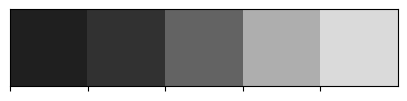

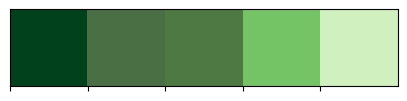

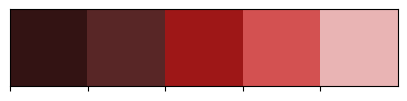

In [7]:
# Define color palettes
colors_dark = ["#1F1F1F", "#313131", '#636363', '#AEAEAE', '#DADADA']
colors_red = ["#331313", "#582626", '#9E1717', '#D35151', '#E9B4B4']
colors_green = ['#01411C', '#4B6F44', '#4F7942', '#74C365', '#D0F0C0']

# Visualize palettes
sns.palplot(colors_dark)
sns.palplot(colors_green)
sns.palplot(colors_red)

In [8]:
# Define labels and image size
labels = ['glioma', 'notumor', 'meningioma', 'pituitary']
image_size = 150

def load_images_from_directory(directory, label_list, image_size):
    """
    Loads images from a directory, resizes them, and associates them with corresponding labels.

    Args:
    - directory (str): Base path of the image folders.
    - label_list (list): List of labels (subfolders within the directory).
    - image_size (int): Target size for resizing the images.

    Returns:
    - images (list): List of processed images.
    - labels (list): List of corresponding labels.
    """
    images = []
    labels = []
    for label in label_list:
        folder_path = os.path.join(directory, label)
        for file_name in tqdm(os.listdir(folder_path), desc=f"Loading {label} images"):
            try:
                file_path = os.path.join(folder_path, file_name)
                img = cv2.imread(file_path)
                if img is not None:  # Check if the image was loaded successfully
                    img = cv2.resize(img, (image_size, image_size))
                    images.append(img)
                    labels.append(label)
            except Exception as e:
                print(f"Error loading {file_name}: {e}")
    return images, labels

# Load training images
train_dir = 'Training'
test_dir = 'Testing'

X_train, y_train = load_images_from_directory(train_dir, labels, image_size)
X_test, y_test = load_images_from_directory(test_dir, labels, image_size)

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Train images: {X_train.shape}, Train labels: {y_train.shape}")
print(f"Test images: {X_test.shape}, Test labels: {y_test.shape}")

Loading pituitary images: 100%|██████████| 400/400 [00:00<00:00, 725.41it/s]


Train images: (5600, 150, 150, 3), Train labels: (5600,)
Test images: (1600, 150, 150, 3), Test labels: (1600,)


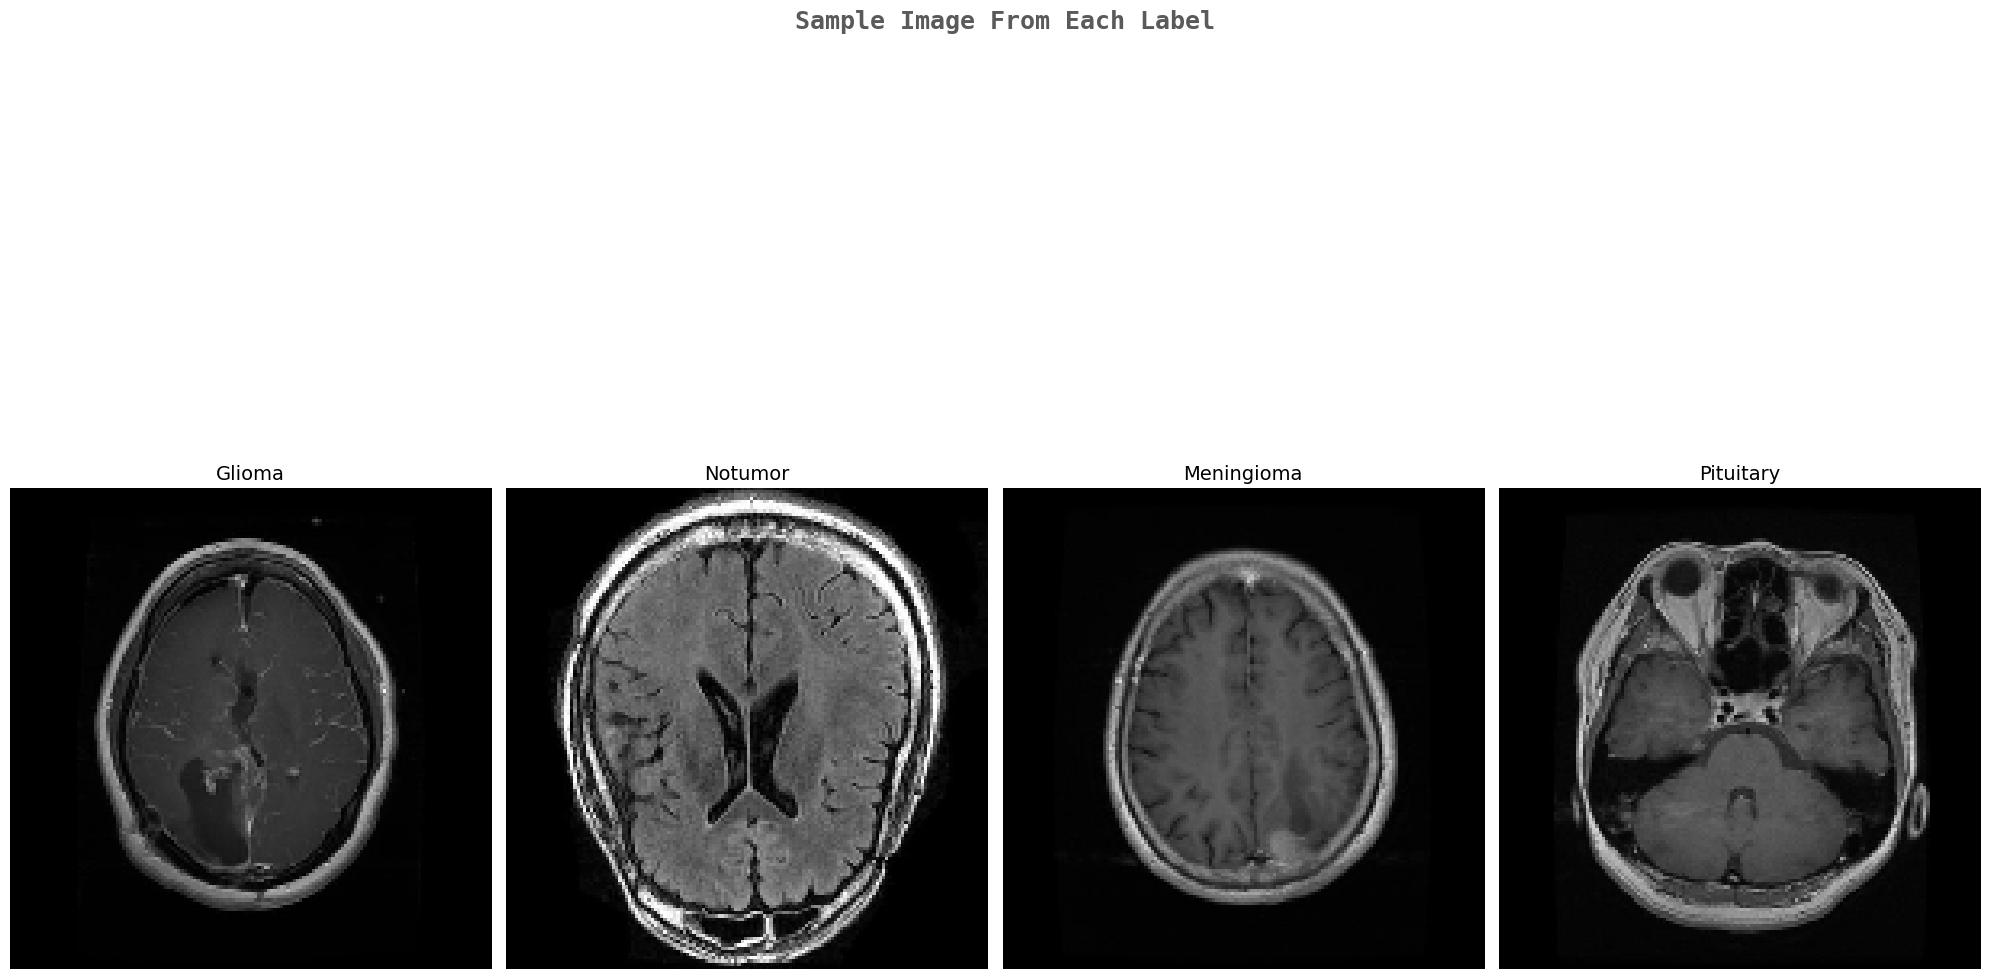

In [9]:
# Display a sample image from each label
fig, axes = plt.subplots(1, len(labels), figsize=(20, 20))  # Adjust layout based on the number of labels
fig.text(s='Sample Image From Each Label', size=18, fontweight='bold',
         fontname='monospace', color=colors_dark[1], y=0.85, x=0.4, alpha=0.8)

# Loop through each label to find and display the first matching sample
for k, label in enumerate(labels):
    # Find the index of the first image with the current label
    try:
        idx = np.where(y_train == label)[0][0]
        axes[k].imshow(X_train[idx])
        axes[k].set_title(label.replace('_', ' ').title(), fontsize=14)
        axes[k].axis('off')
    except IndexError:
        print(f"No image found for label: {label}")
        axes[k].axis('off')
        axes[k].set_title(f"{label} (Not Found)", fontsize=14, color='red')

plt.tight_layout()
plt.show()

In [10]:
# Shuffle the training data to ensure randomness and prevent order bias
X_train, y_train = shuffle(X_train, y_train, random_state=101)

# Confirm the shuffling process
print("Data has been shuffled. First 5 labels after shuffling:")
print(y_train[:5])  # Display the first 5 shuffled labels for verification

Data has been shuffled. First 5 labels after shuffling:
['meningioma' 'notumor' 'pituitary' 'notumor' 'glioma']


In [11]:
X_train.shape

(5600, 150, 150, 3)

In [12]:
# Split the dataset into training (90%) and testing (10%) subsets
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.1, random_state=101
)

# Display dataset sizes for verification
print(f"Training Data: {X_train.shape}, Training Labels: {y_train.shape}")
print(f"Testing Data: {X_test.shape}, Testing Labels: {y_test.shape}")

Training Data: (5040, 150, 150, 3), Training Labels: (5040,)
Testing Data: (560, 150, 150, 3), Testing Labels: (560,)


In [13]:
# Convert labels to numerical indices and one-hot encode them
y_train = to_categorical([labels.index(label) for label in y_train])
y_test = to_categorical([labels.index(label) for label in y_test])

# Verify the transformation
print(f"First 5 training labels (one-hot):\n{y_train[:5]}")
print(f"First 5 testing labels (one-hot):\n{y_test[:5]}")

First 5 training labels (one-hot):
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]]
First 5 testing labels (one-hot):
[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


In [14]:
from sklearn.utils import class_weight

# Get the original (non-one-hot encoded) labels for weight calculation
y_train_labels = np.argmax(y_train, axis=1)

# Calculate class weights based on the distribution of training labels
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert class_weights to a dictionary format expected by model.fit()
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(1.005586592178771), 1: np.float64(1.0015898251192368), 2: np.float64(0.984375), 3: np.float64(1.0088070456365092)}


In [15]:
# Load the pre-trained EfficientNetB0 model with weights from ImageNet
effnet = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

# Add a custom classification head to the pre-trained base model
x = GlobalAveragePooling2D(name="global_avg_pool")(effnet.output)  # Pooling layer to reduce dimensions
x = Dropout(rate=0.5, name="dropout")(x)                           # Dropout for regularization
output = Dense(4, activation='softmax', name="output_layer")(x)    # Dense layer with 4 classes (softmax activation)

# Combine the base model and custom head
model = Model(inputs=effnet.input, outputs=output, name="EfficientNetB0_BrainTumor_Classifier")

# Display the model summary
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_BrainTumor_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 150, 150,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 150, 150,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 150, 150,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 151, 151,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 75, 75,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 75, 75,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 75, 75,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 75, 75,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 75, 75,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 75, 75,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 75, 75,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 75, 75,    │        512 │ block1a_se_excit

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 4,012,672 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [16]:
# Compile the model with a loss function, optimizer, and evaluation metrics
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),  # Explicitly set the learning rate for clarity
    metrics=['accuracy']
)

# Define callbacks for monitoring and optimizing the training process
# 1. TensorBoard: Logs training details for visualization
tensorboard_callback = TensorBoard(
    log_dir='logs',
    histogram_freq=1,  # Enable histograms for weights and biases
    write_graph=True,  # Visualize the computational graph
    update_freq='epoch'  # Log metrics at the end of every epoch
)

# 2. ModelCheckpoint: Save the best model during training based on validation accuracy
checkpoint_callback = ModelCheckpoint(
    filepath="effnet.keras",  # Save the model in Keras format
    monitor="val_accuracy",   # Monitor validation accuracy
    save_best_only=True,      # Save only the best version of the model
    mode="max",               # Look for the maximum value of the monitored metric
    verbose=1                 # Display a message when the model is saved
)

# 3. ReduceLROnPlateau: Dynamically reduce the learning rate when performance plateaus
reduce_lr_callback = ReduceLROnPlateau(
    monitor="val_accuracy",   # Monitor validation accuracy
    factor=0.3,               # Factor to reduce the learning rate by
    patience=2,               # Number of epochs to wait before reducing the rate
    min_delta=0.001,          # Minimum improvement to reset the patience counter
    mode="max",               # Look for a maximum value of the monitored metric
    verbose=1                 # Display a message when the learning rate is reduced
)

# List of callbacks to use during model training
callbacks = [tensorboard_callback, checkpoint_callback, reduce_lr_callback]

In [17]:
# Initialize ImageDataGenerator for data augmentation
data_generator = ImageDataGenerator(
    rotation_range=20,          # Rotate images by up to 20 degrees
    width_shift_range=0.1,      # Shift images horizontally by up to 10% of the width
    height_shift_range=0.1,     # Shift images vertically by up to 10% of the height
    shear_range=0.1,            # Apply shear transformation
    zoom_range=0.1,             # Zoom in or out by up to 10%
    horizontal_flip=True,       # Randomly flip images horizontally
    vertical_flip=False,        # Vertical flip usually not recommended for medical images unless justified
    brightness_range=[0.8, 1.2], # Randomly vary brightness (80% to 120%)
    rescale=1./255              # Normalize pixel values to [0, 1] range
)

# Note: This ImageDataGenerator needs to be used with model.fit() for augmented data.
# For example: model.fit(data_generator.flow(X_train, y_train, batch_size=32), ...)

In [18]:
# Train the model with specified parameters and callbacks
history = model.fit(
    data_generator.flow(X_train, y_train, batch_size=32),  # Use data_generator for augmented training data
    validation_data=(X_test, y_test),  # Use validation_data for evaluation on non-augmented test set
    epochs=12,  # Number of epochs for training
    verbose=1,  # Display progress bar during training
    callbacks=callbacks,  # List of callbacks
    class_weight=class_weights_dict,  # Apply class weights to handle imbalance
    shuffle=True  # Shuffle the training data before each epoch
)

Epoch 1/12
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7824 - loss: 0.5669
Epoch 1: val_accuracy improved from None to 0.34107, saving model to effnet.keras

Epoch 1: finished saving model to effnet.keras
158/158 ━━━━━━━━━━━━━━━━━━━━ 756s 4s/step - accuracy: 0.8442 - loss: 0.4184 - val_accuracy: 0.3411 - val_loss: 4.6435 - learning_rate: 0.0010
Epoch 2/12
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9153 - loss: 0.2371
Epoch 2: val_accuracy did not improve from 0.34107
158/158 ━━━━━━━━━━━━━━━━━━━━ 673s 4s/step - accuracy: 0.9212 - loss: 0.2281 - val_accuracy: 0.1804 - val_loss: 12.6790 - learning_rate: 0.0010
Epoch 3/12
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9393 - loss: 0.1633
Epoch 3: val_accuracy did not improve from 0.34107

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
158/158 ━━━━━━━━━━━━━━━━━━━━ 666s 4s/step - accuracy: 0.9435 - loss: 0.1533 - val_accuracy: 0.1893 - val_loss: 223.7462 - learning_rate: 0.0010
Epoch 4

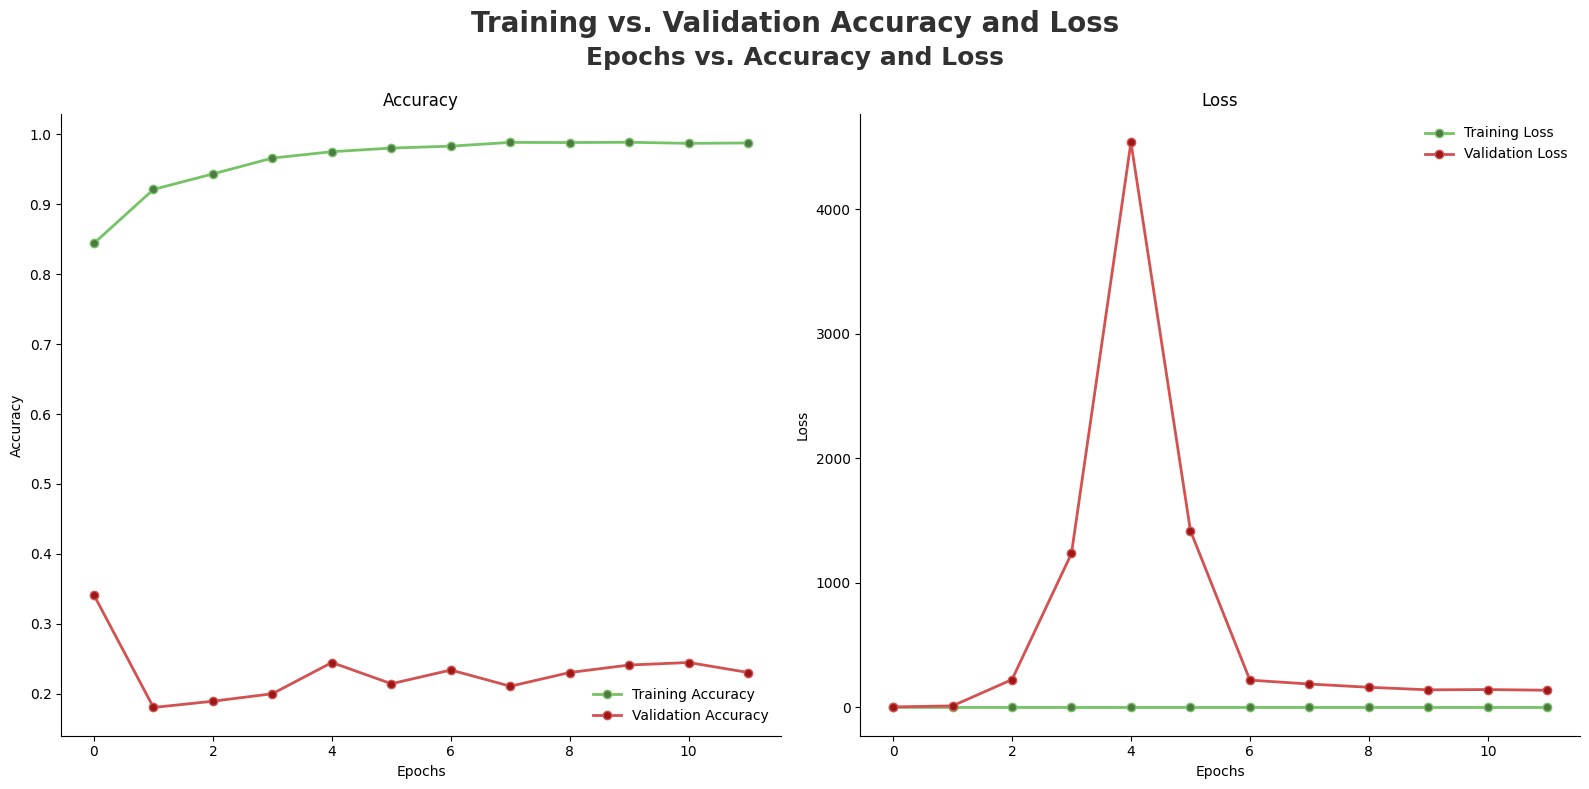

In [19]:
# Suppress warnings for clean output
filterwarnings('ignore')

# Set number of epochs for plotting
epochs = range(12)

# Create a figure and axes for plotting both accuracy and loss
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

# Extract metrics from training history
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

# Title and overall text customization for the plots
fig.suptitle('Training vs. Validation Accuracy and Loss', fontsize=20, fontweight='bold', color=colors_dark[1])
fig.text(0.5, 0.92, 'Epochs vs. Accuracy and Loss', ha='center', va='center', fontsize=18, fontweight='bold', color=colors_dark[1])

# Plot the training and validation accuracy
sns.despine()
ax[0].plot(epochs, train_acc, marker='o', markerfacecolor=colors_green[2], color=colors_green[3], label='Training Accuracy', linewidth=2)
ax[0].plot(epochs, val_acc, marker='o', markerfacecolor=colors_red[2], color=colors_red[3], label='Validation Accuracy', linewidth=2)
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend(loc='lower right', frameon=False)

# Plot the training and validation loss
sns.despine()
ax[1].plot(epochs, train_loss, marker='o', markerfacecolor=colors_green[2], color=colors_green[3], label='Training Loss', linewidth=2)
ax[1].plot(epochs, val_loss, marker='o', markerfacecolor=colors_red[2], color=colors_red[3], label='Validation Loss', linewidth=2)
ax[1].set_title('Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend(loc='upper right', frameon=False)

# Show the plots
fig.tight_layout()
fig.subplots_adjust(top=0.85)  # Adjust the top space to avoid overlap with title
plt.show()

In [20]:
# Make predictions on the test dataset
predictions = model.predict(X_test)

# Convert the prediction probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Convert the one-hot encoded ground truth labels to class labels
true_classes = np.argmax(y_test, axis=1)

18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step


In [21]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       147
           1       0.38      0.04      0.06       142
           2       0.22      0.74      0.34       120
           3       0.26      0.23      0.25       151

    accuracy                           0.23       560
   macro avg       0.22      0.25      0.16       560
weighted avg       0.22      0.23      0.16       560



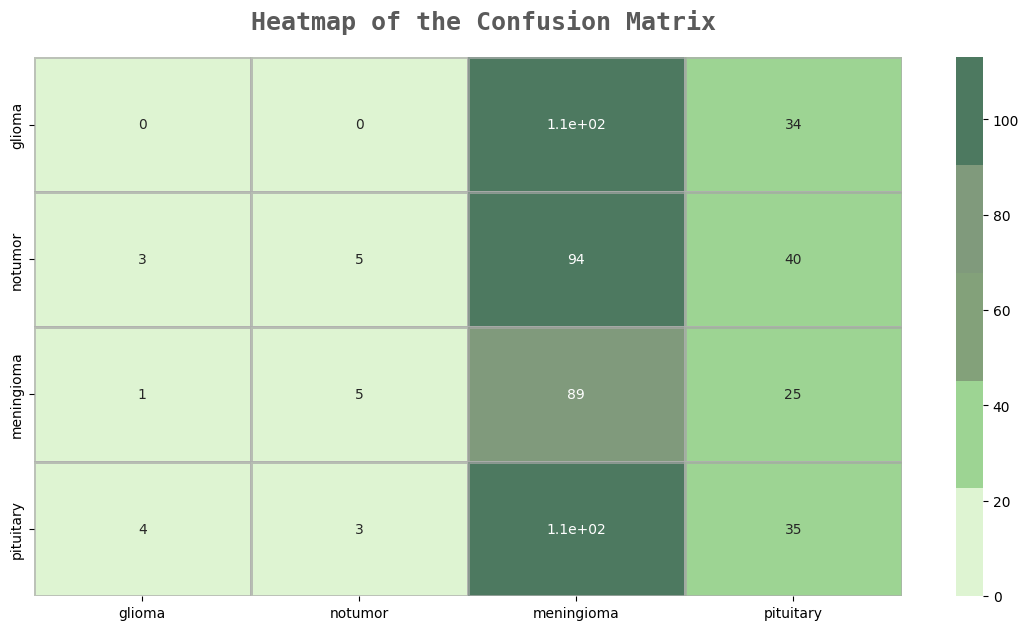

In [22]:
# Create the confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)

# Set up the plot with size and formatting
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Plot the heatmap for the confusion matrix
sns.heatmap(conf_matrix,
            ax=ax,
            xticklabels=labels,
            yticklabels=labels,
            annot=True,
            cmap=colors_green[::-1],
            alpha=0.7,
            linewidths=2,
            linecolor=colors_dark[3])

# Add title text to the plot
fig.text(s='Heatmap of the Confusion Matrix',
         size=18,
         fontweight='bold',
         fontname='monospace',
         color=colors_dark[1],
         y=0.92,
         x=0.28,
         alpha=0.8)

# Display the plot
plt.show()